# Análisis Exploratorio avanzado y segmentación
Melisa Mendizabal - Belen Monterroso - Renato Rojas

## 1. Carga, armonización y calidad de datos
### Cargue los archivos, identifique su procedencia, seleccione las columnas requeridas y homologue sus tipos. 

Se cargaron los cuatro archivos trimestrales de 2025 de la base de Personas de la ENEIC, cada uno leído individualmente desde Excel y convertido a Parquet para controlar el consumo de memoria. Los archivos aportaron 51588, 51167, 51583 y 49338 registros respectivamente, para un total de 203676 registros antes de aplicar cualquier filtro. Antes de unirlos fue necesario homologar los tipos de las variables categóricas, ya que columnas como P05C16, P03A03A, DOMINIO y OCUPADOS venían con formatos inconsistentes entre archivos, en algunos casos como texto numérico con decimales por la presencia de valores ausentes en pandas. Una vez homologadas a una representación de texto consistente, los cuatro archivos se unieron con unionByName, e identificamos cada registro con su archivo de origen y con las columnas derivadas periodo archivo, año archivo y trimestre calendario.

In [11]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [12]:
import os
import pandas as pd
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("Lab7_ENEIC")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

mydir = "/opt/app/working_dir/lab7/"

COLUMNAS_REQUERIDAS = [
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE",
    "OCUPADOS", "P05C16", "P05D01",
    "P02A03", "P05C07A", "P05C07B", "P05H01A",
    "P03A03A", "DOMINIO",
]

# archivo: (nombre_excel, periodo_archivo, anio_archivo, trimestre_calendario)
ARCHIVOS_2025 = {
    "2025T1": ("Personas_ENEIC_T1_2025.xlsx", 2025, 1),
    "2025T2": ("Personas-ENEIC-T2-2025.xlsx", 2025, 2),
    "2025T3": ("Base-de-datos-Personas-ENEIC-III-2025.xlsx", 2025, 3),
    "2025T4": ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx", 2025, 4),
}
ARCHIVO_2026 = {"2026T1": ("Base-de-datos-Personas-ENEIC-I-2026.xlsx", 2026, 1)}

def excel_a_parquet(nombre_excel, periodo_archivo, anio_archivo, trimestre_cal):
    print(f"Leyendo {nombre_excel}...", flush=True)
    ruta_in = os.path.join(mydir, nombre_excel)
    df_pd = pd.read_excel(
        ruta_in,
        engine="openpyxl",
        usecols=lambda c: c.strip().upper() in COLUMNAS_REQUERIDAS,
    )
    print(f"  -> {len(df_pd)} filas leídas", flush=True)

    df_pd.columns = [c.strip().upper() for c in df_pd.columns]
    df_pd = df_pd[[c for c in COLUMNAS_REQUERIDAS if c in df_pd.columns]]

    def normalizar_codigo(valor):
        if pd.isna(valor):
            return None
        try:
            f = float(valor)
            if f.is_integer():
                return str(int(f))
            return str(valor).strip()
        except (ValueError, TypeError):
            return str(valor).strip()
    
    # dentro de excel_a_parquet, reemplaza el for anterior por:
    for c in ["P05C16", "P03A03A", "DOMINIO", "OCUPADOS"]:
        if c in df_pd.columns:
            df_pd[c] = df_pd[c].apply(normalizar_codigo)

    for c in ["NUM_HOGAR", "NUM_PERSONA", "ANIO", "TRIMESTRE"]:
        if c in df_pd.columns:
            df_pd[c] = pd.to_numeric(df_pd[c], errors="coerce")

    for c in ["P02A03", "P05C07A", "P05C07B", "P05H01A", "P05D01", "FACTOR"]:
        if c in df_pd.columns:
            df_pd[c] = pd.to_numeric(df_pd[c], errors="coerce")

    df_pd["archivo_origen"] = nombre_excel
    df_pd["periodo_archivo"] = periodo_archivo
    df_pd["anio_archivo"] = anio_archivo
    df_pd["trimestre_calendario"] = trimestre_cal

    ruta_out = os.path.join(mydir, "raw_parquet", f"{periodo_archivo}.parquet")
    os.makedirs(os.path.dirname(ruta_out), exist_ok=True)
    df_pd.to_parquet(ruta_out, index=False)
    return ruta_out

In [13]:
df_2025_raw.select("P05C16").distinct().show(50, truncate=False)

+------+
|P05C16|
+------+
|1.0   |
|9.0   |
|5.0   |
|6.0   |
|4.0   |
|7.0   |
|2.0   |
|8.0   |
|3.0   |
|NULL  |
+------+



In [14]:
import os
print(os.listdir(mydir))


['Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'Personas-ENEIC-T2-2025.xlsx', 'Personas_ENEIC_T1_2025.xlsx', 'preparado', 'raw_parquet']


### Una los cuatro archivos de 2025 mediante unionByName.

In [15]:
rutas_2025 = [excel_a_parquet(nom, per, an, tc) for per,(nom,an,tc) in ARCHIVOS_2025.items()]
dfs_2025 = [spark.read.parquet(r) for r in rutas_2025]

df_2025_raw = dfs_2025[0]
for df in dfs_2025[1:]:
    df_2025_raw = df_2025_raw.unionByName(df, allowMissingColumns=True)

df_2025_raw.printSchema()
df_2025_raw.show(5, truncate=False)

# Registros por archivo, antes de filtros
df_2025_raw.groupBy("archivo_origen").count().orderBy("archivo_origen").show()

Leyendo Personas_ENEIC_T1_2025.xlsx...
  -> 51588 filas leídas
Leyendo Personas-ENEIC-T2-2025.xlsx...
  -> 51167 filas leídas
Leyendo Base-de-datos-Personas-ENEIC-III-2025.xlsx...
  -> 51583 filas leídas
Leyendo Base-de-datos-Personas-ENEIC-IV-2025.xlsx...
  -> 49338 filas leídas
root
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- P02A03: long (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable =

### Cantidad y porcentaje de faltantes por variable seleccionada, antes de aplicar los filtros

Sobre los 203676 registros unidos, la variable edad no presentó valores ausentes, y el dominio tampoco. En cambio, antigüedad en años, antigüedad en meses, horas habituales y ocupados en la semana de referencia mostraron 56.69 por ciento de valores ausentes cada una, lo mismo que la categoría ocupacional. El nivel educativo tuvo 12.93 por ciento de ausencia, y el salario mensual presentó el porcentaje más alto, con 73.97 por ciento de valores ausentes. Estos porcentajes altos se explican porque la mayoría de esas preguntas solo aplican a personas ocupadas y asalariadas, así que es esperable que buena parte de la población encuestada no tenga respuesta en esos campos.

In [16]:
variables = ["P02A03","P05C07A","P05C07B","P05H01A","P03A03A","P05C16","DOMINIO","OCUPADOS","P05D01"]
total = df_2025_raw.count()

expr = [F.round(F.sum(F.col(c).isNull().cast("int"))/total*100, 2).alias(c) for c in variables]
df_2025_raw.select(expr).show(vertical=True)

-RECORD 0---------
 P02A03   | 0.0   
 P05C07A  | 56.69 
 P05C07B  | 56.69 
 P05H01A  | 56.69 
 P03A03A  | 12.93 
 P05C16   | 56.69 
 DOMINIO  | 0.0   
 OCUPADOS | 56.69 
 P05D01   | 73.97 



### Construcción de variables analíticas y filtros paso a paso (con conteo de exclusión en cada paso)

Partiendo de los 203676 registros iniciales, el primer filtro, que exige estar ocupado, redujo la base a 88222 registros. El segundo filtro, que exige ser asalariado según las categorías uno a cuatro de P05C16, la redujo a 53025 registros. A partir de ahí, los filtros de salario positivo, edad válida, meses de antigüedad entre cero y once, antigüedad no negativa, antigüedad menor o igual a la edad, y horas semanales entre uno y ciento sesenta y ocho, no excluyeron registros adicionales, manteniéndose en 53025 hasta el final. Esto indica que, una vez aplicado el filtro de población de asalariados con salario positivo, los registros restantes ya cumplían de forma natural con los criterios de consistencia numérica. Para 2026, el mismo procedimiento partió de 49843 registros, bajó a 21734 tras el filtro de ocupados, y a 13258 tras el filtro de asalariados, manteniéndose en 13258 en los pasos restantes.

In [17]:
def preparar(df, poblacion_nombre):
    df = (
        df
        .withColumn("edad", F.col("P02A03").cast("double"))
        .withColumn("antiguedad_anios", F.col("P05C07A").cast("double"))
        .withColumn("antiguedad_meses", F.col("P05C07B").cast("double"))
        .withColumn("horas_semanales", F.col("P05H01A").cast("double"))
        .withColumn("salario_mensual", F.col("P05D01").cast("double"))
        .withColumn("ocupado", F.col("OCUPADOS").cast("int"))
        .withColumn("categoria_ocupacional", F.trim(F.col("P05C16")))
        .withColumn(
            "nivel_educativo",
            F.when(F.trim(F.col("P03A03A")) == "0", "0")          # 0 = "ninguno", NO es faltante
             .when(F.col("P03A03A").isNull(), "DESCONOCIDO")
             .otherwise(F.trim(F.col("P03A03A")))
        )
        .withColumn("dominio", F.when(F.col("DOMINIO").isNull(), "DESCONOCIDO").otherwise(F.trim(F.col("DOMINIO"))))
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses")/F.lit(12))
    )

    pasos = {}
    pasos["0_inicial"] = df.count()

    df = df.filter(F.col("ocupado") == 1)
    pasos["1_ocupados"] = df.count()

    df = df.filter(F.col("categoria_ocupacional").isin("1","2","3","4"))
    pasos["2_asalariados"] = df.count()

    df = df.filter(F.col("salario_mensual").isNotNull() & ~F.isnan("salario_mensual") & (F.col("salario_mensual") > 0))
    pasos["3_salario_valido"] = df.count()

    df = df.filter(F.col("edad").isNotNull() & ~F.isnan("edad") & (F.col("edad") >= 15))
    pasos["4_edad_valida"] = df.count()

    df = df.filter(F.col("antiguedad_meses").isNotNull() & (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11))
    pasos["5_meses_validos"] = df.count()

    df = df.filter(F.col("antiguedad").isNotNull() & (F.col("antiguedad") >= 0))
    pasos["6_antiguedad_no_negativa"] = df.count()

    df = df.filter(F.col("antiguedad") <= F.col("edad"))
    pasos["7_antiguedad_menor_igual_edad"] = df.count()

    df = df.filter(F.col("horas_semanales").isNotNull() & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168))
    pasos["8_horas_validas"] = df.count()

    print(f"--- Exclusión paso a paso: {poblacion_nombre} ---")
    for k, v in pasos.items():
        print(k, v)

    return df

df_2025_final = preparar(df_2025_raw, "2025")

--- Exclusión paso a paso: 2025 ---
0_inicial 203676
1_ocupados 88222
2_asalariados 53025
3_salario_valido 53025
4_edad_valida 53025
5_meses_validos 53025
6_antiguedad_no_negativa 53025
7_antiguedad_menor_igual_edad 53025
8_horas_validas 53025


### Unicidad de la clave periodo_archivo + NUM_HOGAR + NUM_PERSONA

Al verificar la combinación de periodo archivo, número de hogar y número de persona sobre la base final de 2025, se encontraron cero combinaciones duplicadas, lo que confirma que cada persona observada en cada trimestre queda representada por un único registro dentro de ese periodo, sin necesidad de eliminar filas adicionales.

In [18]:
claves = df_2025_final.groupBy("periodo_archivo","NUM_HOGAR","NUM_PERSONA").count()
duplicadas = claves.filter(F.col("count") > 1)
print("Combinaciones de clave duplicadas:", duplicadas.count())

# Inspeccionar si son repeticiones exactas o registros en conflicto (NO usar dropDuplicates)
registros_dup = df_2025_final.join(
    duplicadas.select("periodo_archivo","NUM_HOGAR","NUM_PERSONA"),
    on=["periodo_archivo","NUM_HOGAR","NUM_PERSONA"], how="inner"
)
registros_dup.orderBy("periodo_archivo","NUM_HOGAR","NUM_PERSONA").show(50, truncate=False)

Combinaciones de clave duplicadas: 0
+---------------+---------+-----------+------+----+---------+--------+------+------+------+-------+-------+-------+-------+-------+--------------+------------+--------------------+----+----------------+----------------+---------------+---------------+-------+---------------------+---------------+----------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|FACTOR|ANIO|TRIMESTRE|OCUPADOS|P05C16|P05D01|P02A03|P05C07A|P05C07B|P05H01A|P03A03A|dominio|archivo_origen|anio_archivo|trimestre_calendario|edad|antiguedad_anios|antiguedad_meses|horas_semanales|salario_mensual|ocupado|categoria_ocupacional|nivel_educativo|antiguedad|
+---------------+---------+-----------+------+----+---------+--------+------+------+------+-------+-------+-------+-------+-------+--------------+------------+--------------------+----+----------------+----------------+---------------+---------------+-------+---------------------+---------------+----------+
+---------------+---------+---------

### Procesar 2026 igual, y guardar ambos por separado en Parquet

In [19]:
rutas_2026 = [excel_a_parquet(nom, per, an, tc) for per,(nom,an,tc) in ARCHIVO_2026.items()]
df_2026_raw = spark.read.parquet(rutas_2026[0])
df_2026_final = preparar(df_2026_raw, "2026")

df_2025_final.write.mode("overwrite").parquet(mydir + "preparado/personas_2025_preparado.parquet")
df_2026_final.write.mode("overwrite").parquet(mydir + "preparado/personas_2026_preparado.parquet")

Leyendo Base-de-datos-Personas-ENEIC-I-2026.xlsx...
  -> 49843 filas leídas
--- Exclusión paso a paso: 2026 ---
0_inicial 49843
1_ocupados 21734
2_asalariados 13258
3_salario_valido 13258
4_edad_valida 13258
5_meses_validos 13258
6_antiguedad_no_negativa 13258
7_antiguedad_menor_igual_edad 13258
8_horas_validas 13258


### Responda:
### ¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?
El archivo del cuarto trimestre de 2025 trae 302 columnas originales, mientras que los otros tres trimestres traen 270. Si se apilaran por posición, cada columna del archivo más ancho quedaría desplazada respecto a las columnas equivalentes de los demás archivos, mezclando variables distintas bajo el mismo nombre. Por eso se utilizó unionByName, que empareja las columnas por su nombre real y no por el orden en que aparecen, evitando ese desplazamiento.



### ¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?
Un dato ausente porque la pregunta no corresponde ocurre cuando la estructura de la encuesta hace que esa pregunta simplemente no se le formule a la persona, por ejemplo las preguntas sobre condiciones laborales no aplican a alguien que no está ocupado. Una respuesta no registrada, en cambio, es un caso donde la pregunta sí correspondía a esa persona, pero por algún motivo no se capturó la respuesta durante el levantamiento. Tratar ambos casos de la misma manera sería un error, porque el primero refleja una regla de diseño del cuestionario y el segundo refleja una omisión real de información.



### ¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?
La ENEIC tiene un diseño longitudinal con rotación, lo que significa que una misma persona puede ser entrevistada en más de un trimestre de forma legítima. Si esas apariciones repetidas se eliminaran como si fueran duplicados, se perdería información válida del panel y se distorsionaría el análisis, ya que no se trata de un error de captura sino de una característica esperada del diseño muestral.

### ¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?
La base final de 53025 registros para 2025 corresponde únicamente a las personas que, dentro de la muestra encuestada, cumplieron con los criterios de edad, ocupación, condición de asalariado y salario positivo, y además todas las métricas se calcularon sin ponderar por el factor de expansión. Al no aplicar esa ponderación, los resultados describen exclusivamente a los registros analizados dentro de la muestra, y no pueden interpretarse como una estimación representativa de toda la población trabajadora de Guatemala, para lo cual sí sería necesario usar el factor de expansión.

## 2. Estadística descriptiva y preguntas de exploración
Importación de librerías necesarias


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

### Tabla de estadística descriptiva
• Salario mensual.
• Edad.
• Antigüedad.
• Horas habituales de trabajo.

In [21]:
from pyspark.sql import functions as F

variables_num = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

filas = []
for v in variables_num:
    agg = df_2025_final.select(
        F.count(F.col(v)).alias("n"),
        F.mean(F.col(v)).alias("media"),
        F.stddev(F.col(v)).alias("desv_std"),
        F.min(F.col(v)).alias("minimo"),
        F.max(F.col(v)).alias("maximo"),
    ).collect()[0]
    p25, mediana, p75, p95 = df_2025_final.approxQuantile(v, [0.25, 0.5, 0.75, 0.95], 0.001)
    filas.append({
        "variable": v, "n": agg["n"], "media": agg["media"], "mediana": mediana,
        "desv_std": agg["desv_std"], "minimo": agg["minimo"], "maximo": agg["maximo"],
        "p25": p25, "p75": p75, "p95": p95,
    })

resumen_pd = pd.DataFrame(filas)
resumen_pd

,variable,n,media,mediana,desv_std,minimo,maximo,p25,p75,p95
0,salario_mensual,53025,3421.684206,3000.0,2902.108964,1.0,99000.0,1800.0,4000.0,8000.000000
1,edad,53025,35.187647,33.0,13.520902,15.0,89.0,24.0,44.0,61.000000
2,antiguedad,53025,5.558828,2.0,7.831017,0.0,70.0,0.5,7.0,21.333333
3,horas_semanales,53025,46.307402,45.0,18.630407,1.0,126.0,40.0,55.0,80.000000


Sobre la población analítica de 2025, compuesta por 53025 observaciones, el salario mensual presenta una media de 3421.68 quetzales, una mediana de 3000 quetzales, una desviación estándar de 2902.11, con un mínimo de 1 quetzal y un máximo de 99000 quetzales; los percentiles 25, 75 y 95 se ubican en 1800, 4000 y 8000 quetzales respectivamente. La edad tiene una media de 35.19 años, mediana de 33 años, desviación estándar de 13.52, con un rango de 15 a 89 años. La antigüedad muestra una media de 5.56 años frente a una mediana de apenas 2 años, con una desviación estándar de 7.83 y un máximo de 70 años. Las horas habituales de trabajo presentan una media de 46.31 horas semanales, mediana de 45, con un rango de 1 a 126 horas.


Responda con evidencia gráfica:


### ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?
Las gráficas de barras muestran que la categoría ocupacional más frecuente es la de empleado de empresa privada, seguida de empleado jornalero o peón, mientras que empleado de gobierno y servicio doméstico tienen menor participación. En nivel educativo, las categorías intermedias concentran la mayor cantidad de registros, mientras que los niveles más altos y el nivel cero, correspondiente a ninguno, tienen menor representación. En cuanto a dominio, la distribución muestra concentración desigual entre las distintas zonas geográficas cubiertas por la encuesta, con algunas zonas aportando bastante más observaciones que otras.

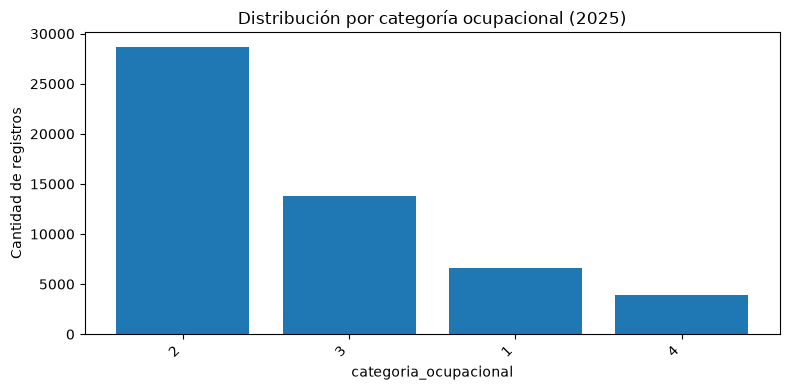

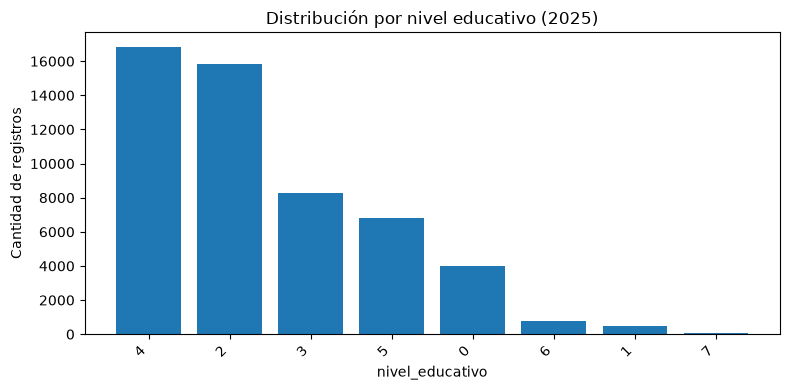

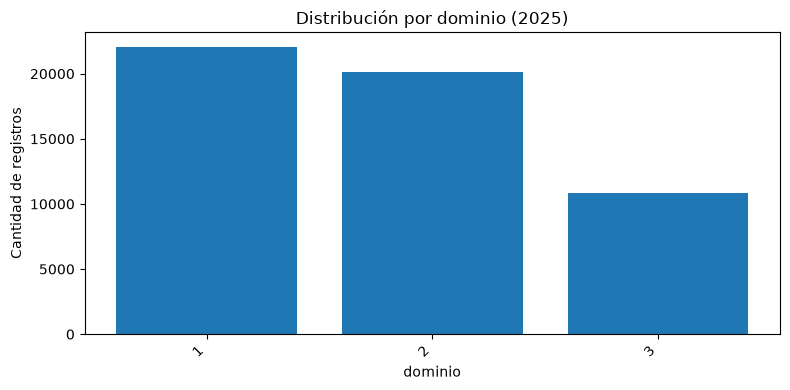

In [22]:
def graficar_conteo(columna, titulo):
    conteo = df_2025_final.groupBy(columna).count().orderBy(F.desc("count")).toPandas()
    plt.figure(figsize=(8, 4))
    plt.bar(conteo[columna].astype(str), conteo["count"])
    plt.title(titulo)
    plt.xlabel(columna)
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return conteo

conteo_ocup = graficar_conteo("categoria_ocupacional", "Distribución por categoría ocupacional (2025)")
conteo_educ = graficar_conteo("nivel_educativo", "Distribución por nivel educativo (2025)")
conteo_dom  = graficar_conteo("dominio", "Distribución por dominio (2025)")

### ¿El salario presenta una distribución simétrica o asimétrica?
El histograma del salario mensual, tanto en escala normal como en escala logarítmica, muestra una distribución claramente asimétrica hacia la derecha, con una cola larga de salarios altos y la gran mayoría de las observaciones concentradas en valores bajos y medios. La escala logarítmica se usó únicamente para facilitar la visualización de esa concentración, pero el salario en quetzales sin transformar se conserva como variable objetivo para el modelado.

### ¿Qué diferencia existe entre su media y su mediana?
La media del salario mensual es de 3421.68 quetzales, mientras que la mediana es de 3000 quetzales, una diferencia de poco más de cuatrocientos quetzales. Esta diferencia, con la media por encima de la mediana, es consistente con la asimetría positiva observada en el histograma: un número relativamente pequeño de salarios altos, hasta 99000 quetzales en el máximo, jala la media hacia arriba sin mover de forma proporcional a la mediana, que resulta un estadístico más representativo del salario típico de la población analizada.

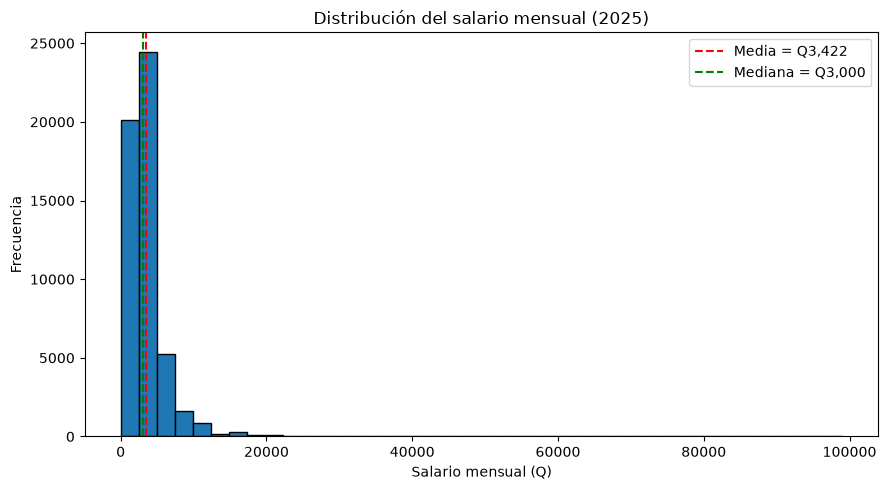

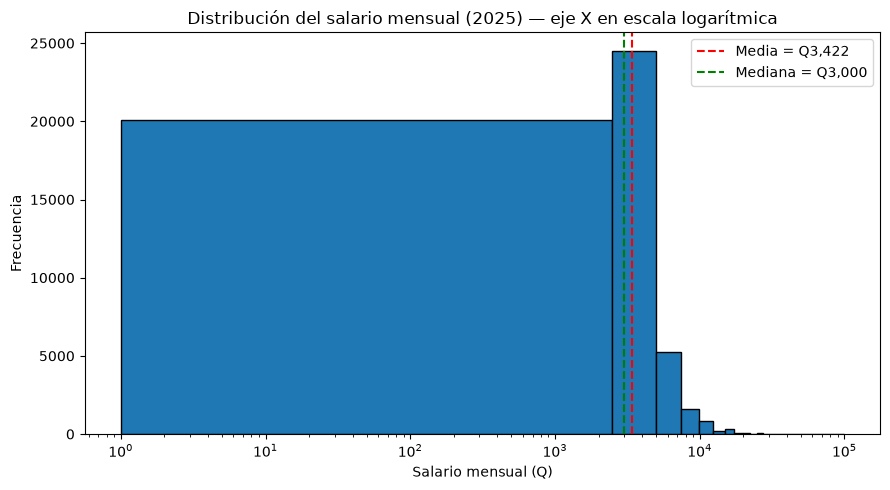

In [23]:
salarios_rdd = df_2025_final.select("salario_mensual").rdd.flatMap(lambda r: r)
bordes, conteos = salarios_rdd.histogram(40)
centros = [(bordes[i] + bordes[i+1]) / 2 for i in range(len(bordes)-1)]
anchos  = [bordes[i+1] - bordes[i] for i in range(len(bordes)-1)]

media_salario = resumen_pd.loc[resumen_pd.variable == "salario_mensual", "media"].values[0]
mediana_salario = resumen_pd.loc[resumen_pd.variable == "salario_mensual", "mediana"].values[0]

def graficar_histograma_salario(log_scale=False):
    plt.figure(figsize=(9, 5))
    plt.bar(centros, conteos, width=anchos, align="center", edgecolor="black")
    plt.axvline(media_salario, color="red", linestyle="--", label=f"Media = Q{media_salario:,.0f}")
    plt.axvline(mediana_salario, color="green", linestyle="--", label=f"Mediana = Q{mediana_salario:,.0f}")
    titulo = "Distribución del salario mensual (2025)"
    if log_scale:
        plt.xscale("log")
        titulo += " — eje X en escala logarítmica"
    plt.title(titulo)
    plt.xlabel("Salario mensual (Q)")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

graficar_histograma_salario(log_scale=False)
graficar_histograma_salario(log_scale=True)

### ¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?
Al agrupar por nivel educativo, el salario mediano aumenta de forma consistente conforme sube el nivel educativo alcanzado, siendo más bajo en los niveles educativos más elementales y más alto en los niveles superiores. Al agrupar por categoría ocupacional, el salario mediano también varía de forma notoria entre categorías, siendo generalmente más bajo en servicio doméstico y más alto en empleo de gobierno o empresa privada, lo que sugiere que tanto la educación como el tipo de relación laboral están asociados con el nivel salarial, aunque esto no implica una relación causal.

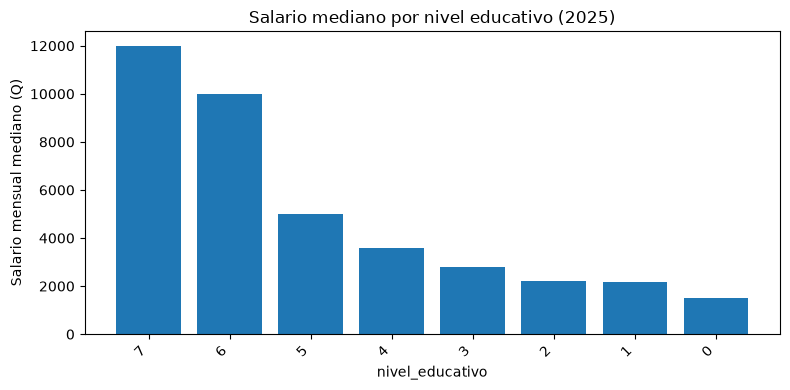

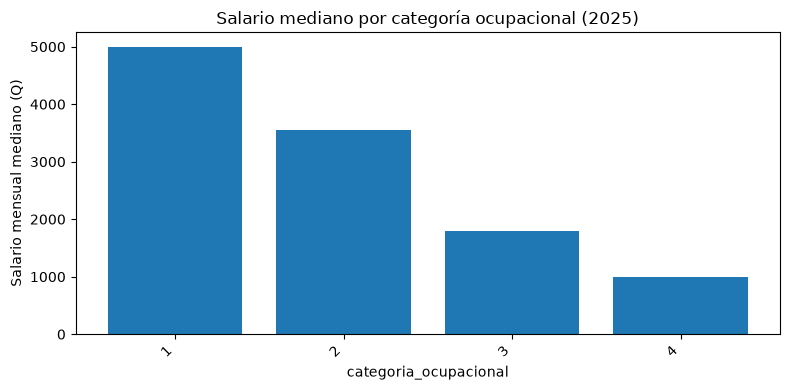

In [24]:
def graficar_mediana_por_grupo(columna, titulo):
    agregado = (
        df_2025_final.groupBy(columna)
        .agg(
            F.count("*").alias("n"),
            F.expr("percentile_approx(salario_mensual, 0.5)").alias("mediana_salario"),
        )
        .orderBy(F.desc("mediana_salario"))
        .toPandas()
    )
    plt.figure(figsize=(8, 4))
    plt.bar(agregado[columna].astype(str), agregado["mediana_salario"])
    plt.title(titulo)
    plt.xlabel(columna)
    plt.ylabel("Salario mensual mediano (Q)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return agregado

tabla_mediana_educ = graficar_mediana_por_grupo("nivel_educativo", "Salario mediano por nivel educativo (2025)")
tabla_mediana_ocup = graficar_mediana_por_grupo("categoria_ocupacional", "Salario mediano por categoría ocupacional (2025)")

### ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?
El tamaño de la muestra analítica se mantiene relativamente estable a lo largo de 2025, con 13419 registros en el primer trimestre, 13492 en el segundo, 13450 en el tercero y 12664 en el cuarto. El salario mediano se mantiene en 3000 quetzales durante el primer y segundo trimestre, y sube a 3200 quetzales en el tercer y cuarto trimestre, lo que indica un ligero incremento del salario mediano hacia la segunda mitad del año, sin cambios drásticos en el tamaño de la muestra que lo expliquen.

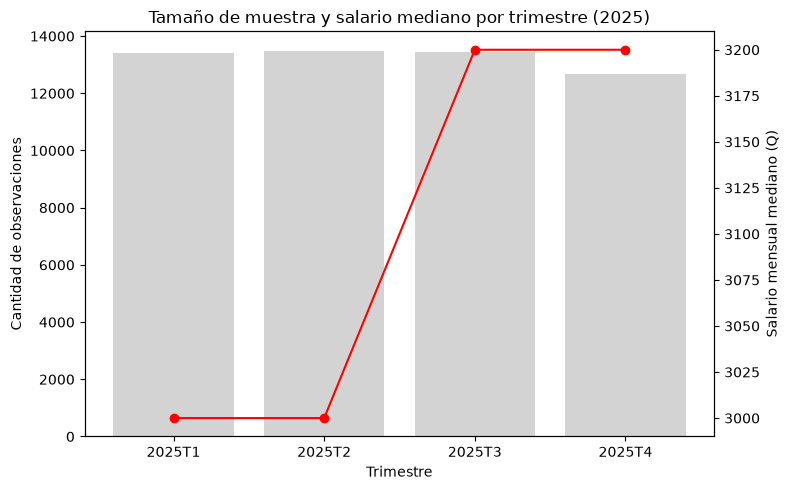

,periodo_archivo,n,mediana_salario
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


In [25]:
por_trimestre = (
    df_2025_final.groupBy("periodo_archivo")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(salario_mensual, 0.5)").alias("mediana_salario"),
    )
    .orderBy("periodo_archivo")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(por_trimestre["periodo_archivo"], por_trimestre["n"], color="lightgray", label="N observaciones")
ax1.set_xlabel("Trimestre")
ax1.set_ylabel("Cantidad de observaciones")

ax2 = ax1.twinx()
ax2.plot(por_trimestre["periodo_archivo"], por_trimestre["mediana_salario"], color="red", marker="o", label="Mediana salario")
ax2.set_ylabel("Salario mensual mediano (Q)")

plt.title("Tamaño de muestra y salario mediano por trimestre (2025)")
fig.tight_layout()
plt.show()

por_trimestre

## 3. Relaciones entre variables numéricas
Utilice VectorAssembler y Correlation.corr() de pyspark.ml.stat para obtener la correlación de Persona entre salario, edad, antigüedad y horas habituales. Presente una matriz de correlaciones con sus etiquetas y un mapa de calor.

Utilizando VectorAssembler y Correlation punto corr de pyspark punto ml punto stat sobre todos los registros elegibles de 2025, se calculó la matriz de correlación de Pearson entre salario mensual, edad, antigüedad y horas semanales, presentada tanto en tabla como en mapa de calor. El salario mensual muestra una correlación positiva pero débil con las otras tres variables, siendo antigüedad la que presenta la asociación lineal más alta con el salario, con un coeficiente de 0.18, seguida de edad con 0.15, y horas semanales con apenas 0.08. Esto sugiere que ni la edad, ni la antigüedad, ni las horas trabajadas explican por sí solas una parte importante de la variabilidad del salario cuando se observan de forma lineal e individual.

En cuanto a la relación entre edad y antigüedad, sí existe una asociación más marcada que las anteriores, con un coeficiente de correlación de 0.49, la más alta de toda la matriz. Esto es coherente con la lógica de que las personas de mayor edad han tenido más tiempo disponible para acumular antigüedad en su ocupación actual, aunque la relación está lejos de ser perfecta, ya que muchas personas mayores pueden tener poca antigüedad si cambiaron de empleo recientemente, y viceversa.

### Relaciones

In [26]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import numpy as np
import matplotlib.pyplot as plt

variables_corr = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

# Correlation.corr requiere una columna vector sin nulos
df_corr = df_2025_final.select(variables_corr).na.drop()

assembler_corr = VectorAssembler(inputCols=variables_corr, outputCol="features_corr")
df_vec = assembler_corr.transform(df_corr)

matriz_corr = Correlation.corr(df_vec, "features_corr", method="pearson").head()[0]
matriz_corr_np = matriz_corr.toArray()

matriz_corr_pd = pd.DataFrame(matriz_corr_np, index=variables_corr, columns=variables_corr)
matriz_corr_pd

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000000,0.147249,0.179574,0.075665
edad,0.147249,1.000000,0.486713,-0.105378
antiguedad,0.179574,0.486713,1.000000,-0.062256
horas_semanales,0.075665,-0.105378,-0.062256,1.000000


### Mapa de calor

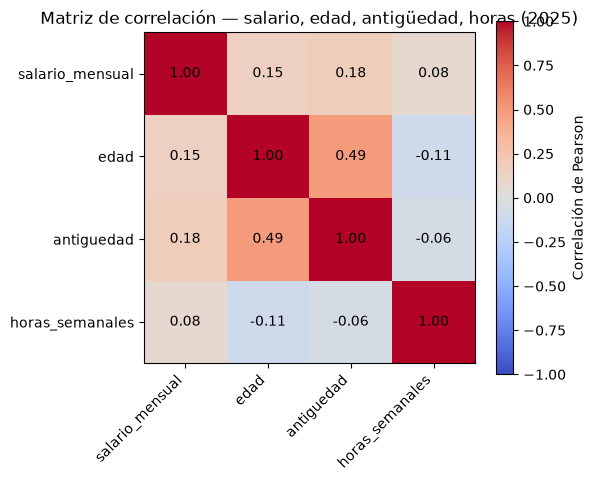

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_corr_np, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables_corr)))
ax.set_yticks(range(len(variables_corr)))
ax.set_xticklabels(variables_corr, rotation=45, ha="right")
ax.set_yticklabels(variables_corr)

for i in range(len(variables_corr)):
    for j in range(len(variables_corr)):
        ax.text(j, i, f"{matriz_corr_np[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, label="Correlación de Pearson")
plt.title("Matriz de correlación — salario, edad, antigüedad, horas (2025)")
plt.tight_layout()
plt.show()

## 4. Segmentación de perfiles mediante KMeans
Pipeline sin salario

In [28]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Variables de clustering: numéricas relevantes para perfiles laborales
vars_cluster_base = ["edad", "antiguedad", "horas_semanales"]
vars_cluster_con_salario = vars_cluster_base + ["salario_mensual"]

df_cluster_input = df_2025_final.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA",
    "nivel_educativo", "categoria_ocupacional", "dominio",
    *vars_cluster_con_salario
).na.drop()

df_cluster_input.count()

53025

Función reutilizable para armar el pipeline, probar K = 2,3,4,5 y evaluar con silueta

Para la segmentación se construyeron dos versiones del pipeline, una usando edad, antigüedad y horas semanales, y otra agregando además el salario mensual, ambas con las variables estandarizadas mediante StandardScaler antes de aplicar KMeans, y evaluadas con el coeficiente de silueta para K igual a 2, 3, 4 y 5. En la versión sin salario, el mejor resultado se obtuvo con K igual a 2, con una silueta de 0.55, superior a los valores obtenidos con 3, 4 y 5 grupos, que se ubicaron entre 0.47 y 0.48. En la versión que incluye salario, la silueta más alta también se dio en K igual a 2, con 0.51, pero fue consistentemente menor que la versión sin salario en todos los valores de K probados.

In [29]:
def evaluar_kmeans(df, variables, etiqueta, ks=(2, 3, 4, 5), seed=42):
    assembler = VectorAssembler(inputCols=variables, outputCol="features_raw")
    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

    df_prep = assembler.transform(df)
    modelo_scaler = scaler.fit(df_prep)
    df_scaled = modelo_scaler.transform(df_prep).cache()

    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")

    resultados = []
    modelos = {}
    for k in ks:
        km = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=seed)
        modelo = km.fit(df_scaled)
        df_pred = modelo.transform(df_scaled)
        silueta = evaluator.evaluate(df_pred)
        resultados.append({"k": k, "silhouette": silueta})
        modelos[k] = (modelo, df_pred)
        print(f"[{etiqueta}] k={k} -> silhouette={silueta:.4f}")

    return pd.DataFrame(resultados), modelos, df_scaled

resultados_sin_salario, modelos_sin_salario, _ = evaluar_kmeans(df_cluster_input, vars_cluster_base, "sin salario")
resultados_con_salario, modelos_con_salario, _ = evaluar_kmeans(df_cluster_input, vars_cluster_con_salario, "con salario")

[sin salario] k=2 -> silhouette=0.5536
[sin salario] k=3 -> silhouette=0.4708
[sin salario] k=4 -> silhouette=0.4799
[sin salario] k=5 -> silhouette=0.4839
[con salario] k=2 -> silhouette=0.5121
[con salario] k=3 -> silhouette=0.3373
[con salario] k=4 -> silhouette=0.3524
[con salario] k=5 -> silhouette=0.3968


### Gráfica comparando silueta por K (ayuda a elegir el mejor K y a decidir si incluir salario)

Dado que incluir el salario como variable de clustering no mejoró la calidad de la segmentación, sino que la empeoró en todos los valores de K evaluados, se decidió no incluirlo en el modelo final de clustering. Esto tiene sentido adicional porque el salario es precisamente la variable que se va a predecir en la etapa de modelado supervisado, así que usarla también como insumo para agrupar introduciría una relación circular entre el análisis exploratorio y el objetivo de predicción.

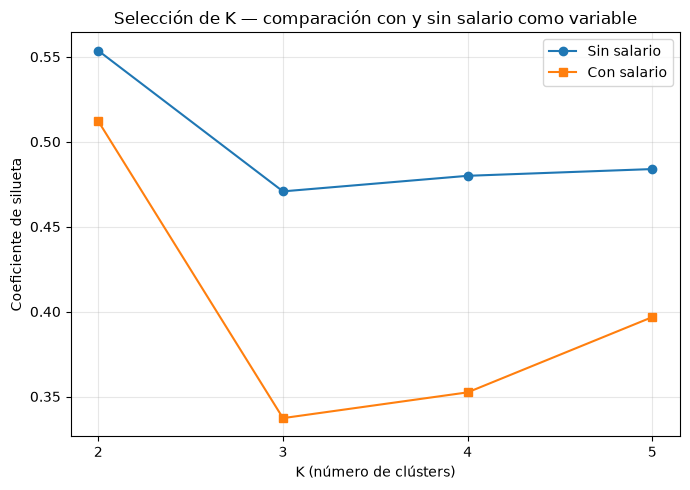

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(resultados_sin_salario["k"], resultados_sin_salario["silhouette"], marker="o", label="Sin salario")
plt.plot(resultados_con_salario["k"], resultados_con_salario["silhouette"], marker="s", label="Con salario")
plt.xlabel("K (número de clústers)")
plt.ylabel("Coeficiente de silueta")
plt.title("Selección de K — comparación con y sin salario como variable")
plt.xticks([2, 3, 4, 5])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Una vez decidido el mejor K describe los clústers

In [31]:
mejor_k = int(resultados_sin_salario.loc[resultados_sin_salario["silhouette"].idxmax(), "k"])  # ajusta si gana "con salario"
modelo_final, df_pred_final = modelos_sin_salario[mejor_k]

perfil_clusters = (
    df_pred_final.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean("edad"), 1).alias("edad_media"),
        F.round(F.mean("antiguedad"), 1).alias("antiguedad_media"),
        F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
        F.round(F.expr("percentile_approx(salario_mensual, 0.5)"), 0).alias("salario_mediano"),
    )
    .orderBy("cluster")
    .toPandas()
)
perfil_clusters

,cluster,n,edad_media,antiguedad_media,horas_media,salario_mediano
0,0,14672,51.3,13.8,41.3,3450.0
1,1,38353,29.0,2.4,48.2,3000.0


### Gráfica de perfiles

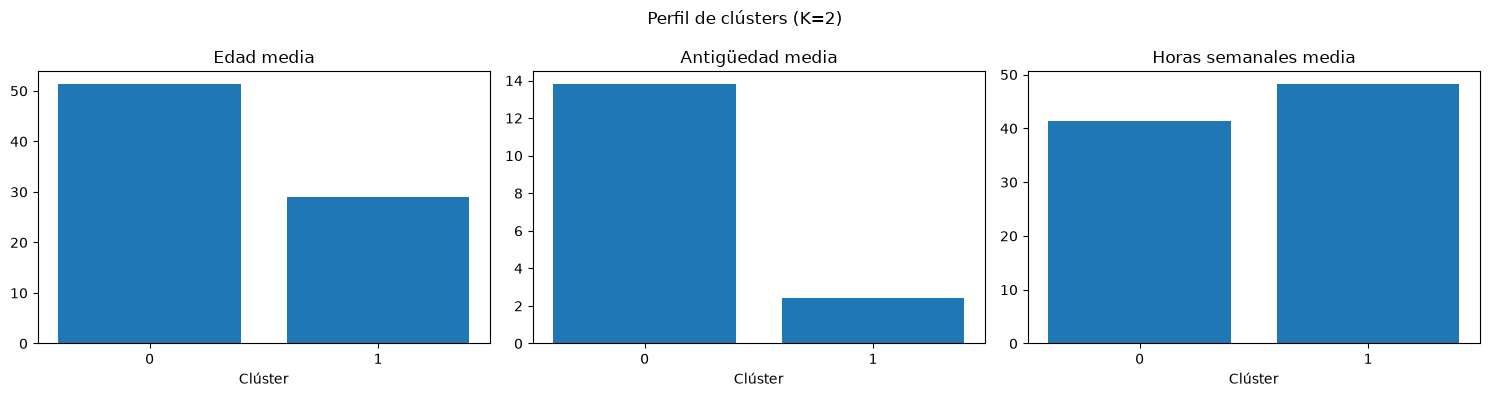

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(
    axes,
    ["edad_media", "antiguedad_media", "horas_media"],
    ["Edad media", "Antigüedad media", "Horas semanales media"],
):
    ax.bar(perfil_clusters["cluster"].astype(str), perfil_clusters[col])
    ax.set_title(titulo)
    ax.set_xlabel("Clúster")

plt.suptitle(f"Perfil de clústers (K={mejor_k})")
plt.tight_layout()
plt.show()

### Distribución de nivel educativo/dominio/categoría por clúster

Con K igual a 2 y sin salario como variable de entrada, se obtuvieron dos grupos claramente diferenciados. El primer clúster, con 14672 personas, agrupa a trabajadores de mayor edad, con una edad media de 51.3 años, antigüedad media de 13.8 años, jornada semanal media de 41.3 horas, y un salario mediano de 3450 quetzales; dentro de este grupo predominan niveles educativos intermedios y bajos, con fuerte presencia de las categorías de empleado de empresa privada y jornalero o peón. El segundo clúster, mucho más numeroso con 38353 personas, agrupa a trabajadores más jóvenes, con edad media de 29 años, antigüedad media de apenas 2.4 años, jornada semanal ligeramente mayor de 48.2 horas, y un salario mediano más bajo de 3000 quetzales; en este grupo también predomina la categoría de empleado de empresa privada, pero con una proporción todavía mayor de personas con niveles educativos intermedios. En conjunto, la segmentación distingue principalmente entre un perfil de trabajadores más consolidados en su puesto, de mayor edad y antigüedad, con salario algo más alto, frente a un perfil de trabajadores más jóvenes y con menor tiempo en su empleo actual, que representa a la mayoría de la muestra analizada.

In [33]:
for col in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    tabla = df_pred_final.groupBy("cluster", col).count().orderBy("cluster", F.desc("count")).toPandas()
    print(f"--- Composición por {col} ---")
    print(tabla)
    print()

--- Composición por nivel_educativo ---
    cluster nivel_educativo  count
0         0               2   4777
1         0               4   3308
2         0               5   2507
3         0               0   2121
4         0               3   1396
5         0               6    347
6         0               1    168
7         0               7     48
8         1               4  13543
9         1               2  11045
10        1               3   6853
11        1               5   4311
12        1               0   1874
13        1               6    424
14        1               1    291
15        1               7     12

--- Composición por categoria_ocupacional ---
   cluster categoria_ocupacional  count
0        0                     2   6242
1        0                     3   3570
2        0                     1   3445
3        0                     4   1415
4        1                     2  22460
5        1                     3  10272
6        1                     1   313

## Exportar y guardar el set de datos ya procesados

In [34]:
rutas_2026 = [excel_a_parquet(nom, per, an, tc) for per, (nom, an, tc) in ARCHIVO_2026.items()]
df_2026_raw = spark.read.parquet(rutas_2026[0])
df_2026_final = preparar(df_2026_raw, "2026")

Leyendo Base-de-datos-Personas-ENEIC-I-2026.xlsx...
  -> 49843 filas leídas
--- Exclusión paso a paso: 2026 ---
0_inicial 49843
1_ocupados 21734
2_asalariados 13258
3_salario_valido 13258
4_edad_valida 13258
5_meses_validos 13258
6_antiguedad_no_negativa 13258
7_antiguedad_menor_igual_edad 13258
8_horas_validas 13258


In [35]:
ruta_prep_2025 = mydir + "preparado/personas_2025_preparado.parquet"
ruta_prep_2026 = mydir + "preparado/personas_2026_preparado.parquet"

df_2025_final.write.mode("overwrite").parquet(ruta_prep_2025)
df_2026_final.write.mode("overwrite").parquet(ruta_prep_2026)

print("2025:", df_2025_final.count(), "filas")
print("2026:", df_2026_final.count(), "filas")

2025: 53025 filas
2026: 13258 filas


### Forma de importar data en otros archivos

In [36]:
df_2025 = spark.read.parquet("/opt/app/working_dir/lab7/preparado/personas_2025_preparado.parquet")
df_2026 = spark.read.parquet("/opt/app/working_dir/lab7/preparado/personas_2026_preparado.parquet")

df_2025.printSchema()
df_2025.show(5)

root
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- P02A03: long (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- cat